In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics
import tensorflow as tf
import os
from collections import Counter
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from tensorflow.keras.regularizers import l2
from collections import Counter
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense, Dropout

In [60]:
df1 = pd.read_csv('/kaggle/input/finally-full-tab-ext-l8/cleaned_full_L8_extract (1).csv')

In [61]:
df2 = pd.read_csv('/kaggle/input/full-landsat-ndvi/full_L8_merged_features_ndvi.csv')

In [62]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40911 entries, 0 to 40910
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UNIQUE_ID          40911 non-null  int64  
 1   file               40911 non-null  object 
 2   AREA               40911 non-null  float64
 3   PADDY_BIN          40911 non-null  float64
 4   HARVESTING_DAY     40911 non-null  float64
 5   YIELD              40911 non-null  float64
 6   SPLIT              40911 non-null  float64
 7   sow_mon            40911 non-null  float64
 8   tran_mon           40911 non-null  float64
 9   har_mon            40911 non-null  float64
 10  start_mon          40911 non-null  float64
 11  end_mon            40911 non-null  float64
 12  sow_period         40911 non-null  float64
 13  sow_to_trans_days  40911 non-null  float64
 14  trans_to_har_days  40911 non-null  float64
 15  crop_type          40911 non-null  float64
 16  NDVI               408

In [63]:
df2_temp = df2[['UNIQUE_ID', 'file', 'NDVI']]

In [64]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40886 entries, 0 to 40885
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UNIQUE_ID          40886 non-null  int64  
 1   file               40886 non-null  object 
 2   AREA               40886 non-null  float64
 3   PADDY_BIN          40886 non-null  float64
 4   HARVESTING_DAY     40886 non-null  float64
 5   YIELD              40886 non-null  float64
 6   SPLIT              40886 non-null  float64
 7   sow_mon            40886 non-null  float64
 8   tran_mon           40886 non-null  float64
 9   har_mon            40886 non-null  float64
 10  start_mon          40886 non-null  float64
 11  end_mon            40886 non-null  float64
 12  sow_period         40886 non-null  float64
 13  sow_to_trans_days  40886 non-null  float64
 14  trans_to_har_days  40886 non-null  float64
 15  crop_type          40886 non-null  float64
 16  features           408

In [65]:
import ast

vec = ast.literal_eval(df1['features'][0])
len(vec)


128

In [66]:
len(df2[['UNIQUE_ID', 'file']].drop_duplicates()) == len(df2)

True

In [67]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40911 entries, 0 to 40910
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UNIQUE_ID          40911 non-null  int64  
 1   file               40911 non-null  object 
 2   AREA               40911 non-null  float64
 3   PADDY_BIN          40911 non-null  float64
 4   HARVESTING_DAY     40911 non-null  float64
 5   YIELD              40911 non-null  float64
 6   SPLIT              40911 non-null  float64
 7   sow_mon            40911 non-null  float64
 8   tran_mon           40911 non-null  float64
 9   har_mon            40911 non-null  float64
 10  start_mon          40911 non-null  float64
 11  end_mon            40911 non-null  float64
 12  sow_period         40911 non-null  float64
 13  sow_to_trans_days  40911 non-null  float64
 14  trans_to_har_days  40911 non-null  float64
 15  crop_type          40911 non-null  float64
 16  NDVI               408

In [68]:
# df = (
#     df1
#     .merge(
#         df2_temp,
#         on=['UNIQUE_ID', 'file'],
#         how='left',
#         validate='one_to_one'   # protects structure
#     )
# )


In [69]:
df = pd.read_csv('/kaggle/input/final-trained-classify-tab/final_trained_classify_tab.csv')

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40886 entries, 0 to 40885
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UNIQUE_ID          40886 non-null  int64  
 1   file               40886 non-null  object 
 2   AREA               40886 non-null  float64
 3   PADDY_BIN          40886 non-null  float64
 4   HARVESTING_DAY     40886 non-null  float64
 5   YIELD              40886 non-null  float64
 6   SPLIT              40886 non-null  float64
 7   sow_mon            40886 non-null  float64
 8   tran_mon           40886 non-null  float64
 9   har_mon            40886 non-null  float64
 10  start_mon          40886 non-null  float64
 11  end_mon            40886 non-null  float64
 12  sow_period         40886 non-null  float64
 13  sow_to_trans_days  40886 non-null  float64
 14  trans_to_har_days  40886 non-null  float64
 15  crop_type          40886 non-null  float64
 16  img                408

In [71]:
df['PADDY_BIN'].value_counts()

PADDY_BIN
0.0    26448
1.0    14438
Name: count, dtype: int64

In [72]:
df['SPLIT'].value_counts()

SPLIT
1.0    36236
0.0     4650
Name: count, dtype: int64

In [73]:
df['cnn_features'][0]

'[0.         0.         0.         0.         0.         0.\n 0.         0.         0.         0.55099976 0.         0.\n 0.         0.         0.         0.         0.         0.\n 0.         0.         0.         0.         0.         0.\n 0.         0.         0.         0.         0.         0.\n 0.         0.         0.         0.         0.         0.\n 0.         0.74557984 0.         0.         0.         0.\n 0.         0.         0.         0.         0.         0.\n 0.         0.         0.         0.         0.         0.\n 0.         0.         0.         0.         0.         0.\n 0.         0.         0.         0.         0.         0.\n 0.         0.         0.         0.         0.         0.\n 0.         0.         0.         0.         0.         0.\n 0.         0.         0.         0.         0.11907025 0.\n 0.         0.18011406 0.         0.         0.         0.\n 0.         0.         0.         0.         0.         0.\n 1.5184244  0.         0.         0.   

In [74]:
import numpy as np

vec = np.fromstring(df['cnn_features'][0].strip('[]'), sep=' ')
len(vec)

128

In [75]:
import numpy as np

df['features'] = df['cnn_features'].apply(
    lambda x: np.fromstring(x.strip('[]'), sep=' ')
)

In [76]:
df['features'].iloc[0].shape

(128,)

In [77]:
print(type(df['features'].iloc[0]))

<class 'numpy.ndarray'>


In [78]:
len(df['features'].loc[0])

128

In [79]:
# len(df['features'].value_counts())

In [80]:
tot_features = np.stack(df['features'].values)  # Now shape = (N, 128)

In [81]:
tot_features_train = np.stack(df['features'][df["SPLIT"]==1].values)

In [82]:
tot_features_test = np.stack(df['features'][df["SPLIT"]==0].values)

In [83]:
print(len(tot_features_train))
len(tot_features_test)

36236


4650

In [84]:
np.save("tot_X_features_L8.npy", tot_features)
np.save("tot_train_features_L8.npy", tot_features_train)
np.save("tot_test_features_L8.npy", tot_features_test)

In [85]:
len(tot_features)

40886

In [86]:
input_features = ["AREA", "start_mon", "end_mon"]
df[input_features].corr() 

,AREA,start_mon,end_mon
AREA,1.000000,0.050134,-0.038909
start_mon,0.050134,1.000000,-0.554837
end_mon,-0.038909,-0.554837,1.000000


In [87]:
df["end_mon"].value_counts()

end_mon
1.0     10379
10.0     7237
2.0      6782
3.0      5856
5.0      5386
9.0      3795
8.0      1451
Name: count, dtype: int64

In [88]:
print('-------skew-------')
print(df["end_mon"].skew())
print(df["start_mon"].skew())
print(df["AREA"].skew())
print('------kurtosis-------')
print(df["end_mon"].kurt())
print(df["start_mon"].kurt())
print(df["AREA"].kurt())

-------skew-------
0.546167070580174
0.04768709067633065
5.428825017632324
------kurtosis-------
-1.3481664346229079
-0.7672880266741391
40.51551016895152


### 🔹 **Skewness**:

* Measures **asymmetry** of the distribution.
* **Ideal skewness** for a perfectly symmetrical (normal) distribution: **0**

**Interpretation:**

| Skew Value  | Interpretation                 |
| ----------- | ------------------------------ |
| ≈ 0         | Symmetrical                    |
| > 0         | Right-skewed (long right tail) |
| < 0         | Left-skewed (long left tail)   |
| > 1 or < -1 | Highly skewed                  |

---

### 🔹 **Kurtosis**:

* Measures **tailedness** (extremes/outliers) of the distribution.
* **Ideal kurtosis**:

  * If using **Pandas** (`.kurt()`): **0** is normal (Fisher’s definition)
  * If using SciPy with `fisher=False`: **3** is normal

**Interpretation:**

| Kurtosis Value (Pandas `.kurt()`) | Interpretation                   |
| --------------------------------- | -------------------------------- |
| ≈ 0                               | Normal-tailed (mesokurtic)       |
| < 0                               | Light tails (platykurtic)        |
| > 0                               | Heavy tails (leptokurtic)        |
| >> 0                              | Very heavy tails (many outliers) |

---

## 📈 Your Output Explained

```python
print('------kurtosis-------')
end_mon    → -1.348  (light tails, fewer outliers than normal)
AREA       → 40.51   (extremely heavy tails — high outlier influence)
```
---

## 🟢 Summary:

| Column      | Skewness | Interpretation          | Kurtosis | Interpretation                       |
| ----------- | -------- | ----------------------- | -------- | ------------------------------------ |
| `end_mon`   | 0.546    | Moderate right-skew     | -1.35    | Light tails (platykurtic)            |
| `start_mon` | 0.047    | Almost symmetric        | -0.77    | Light tails                          |
| `AREA`      | 5.428    | **Highly right-skewed** | 40.52    | **Extremely heavy tails / outliers** |

---

## ✅ Recommendations:

* `start_mon` is fairly normal — no action may be needed.
* `end_mon` is moderately skewed — possibly acceptable, but monitor.
* `AREA` is **highly non-normal** — consider:

  * Applying a **log transform** or **Box-Cox transform**
  * Investigating and handling **outliers**

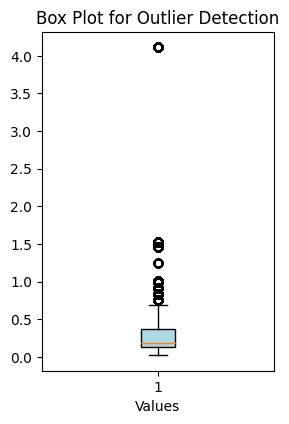

5.428825017632324

In [89]:
plt.figure(figsize=(3, 4.4))
plt.boxplot(df['AREA'], patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.xlabel('Values')
plt.title('Box Plot for Outlier Detection')
plt.show()
df["AREA"].skew()

### 🔹 Step 1: Calculate Q1 and Q3

```python
Q1 = pft_df_1['sow_to_trans_days'].quantile(0.25)
Q3 = pft_df_1['sow_to_trans_days'].quantile(0.75)
```

* `Q1` is the **25th percentile** — the value below which 25% of the data falls.
* `Q3` is the **75th percentile** — the value below which 75% of the data falls.

This gives you the **middle 50%** of the data (also called the **interquartile range**).

---

### 🔹 Step 2: Compute the IQR

```python
IQR = Q3 - Q1
```

* The **Interquartile Range (IQR)** measures the spread of the middle 50% of values.
* It's a robust measure of variability — less sensitive to outliers than standard deviation.

---

### 🔹 Step 3: Define Outlier Bounds

```python
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
```

* These bounds define the **acceptable range** for "non-outlier" data.
* Any data point **below the lower bound or above the upper bound** is considered an **outlier**.
* The factor `1.5` is standard in statistical practice for identifying mild to moderate outliers.

---

### 🔹 Step 4: Filter Outliers

```python
outliers = pft_df_1[
    (pft_df_1['sow_to_trans_days'] < lower_bound) |
    (pft_df_1['sow_to_trans_days'] > upper_bound)
]
```

* This filters the DataFrame to only include rows where `sow_to_trans_days` is outside the defined IQR bounds — i.e., the **outliers**.

---

### 🔹 Step 5: Show Unique Outlier Values

```python
outliers["sow_to_trans_days"].unique()
```

* This shows the **unique outlier values** in the column `sow_to_trans_days`.

---

## ✅ Summary:

You're identifying values in `sow_to_trans_days` that are **statistical outliers** using the IQR method. This is a **non-parametric**, distribution-independent way to detect outliers and is widely used in preprocessing.


In [90]:
Q1 = df['AREA'].quantile(0.25)  
Q3 = df['AREA'].quantile(0.75)  
IQR = Q3 - Q1 

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['AREA'] < lower_bound) | (df['AREA'] > upper_bound)]
outliers["AREA"].unique()

array([0.91, 0.75, 0.84, 4.11, 1.46, 1.53, 1.01, 1.  , 1.25])

In [91]:
df['AREA'].value_counts()

AREA
0.17    3009
1.00    2523
0.13    1990
0.07    1840
0.09    1828
0.25    1655
0.06    1576
0.21    1445
0.50    1429
0.15    1388
0.22    1315
0.11    1288
0.14    1264
0.19    1175
0.31    1012
0.05     980
0.18     908
0.29     787
0.12     678
0.16     674
0.04     646
0.32     625
0.20     622
0.10     595
0.47     595
0.26     541
0.42     536
0.51     536
0.84     536
0.91     536
0.38     516
0.75     485
0.37     480
0.44     480
0.24     423
0.28     358
4.11     339
0.08     330
0.43     305
0.30     304
0.02     296
0.34     292
0.23     271
0.33     212
0.36     185
1.53     178
1.01     178
1.46     178
0.64     161
0.03     137
0.55      65
0.69      64
0.45      59
1.25      58
Name: count, dtype: int64

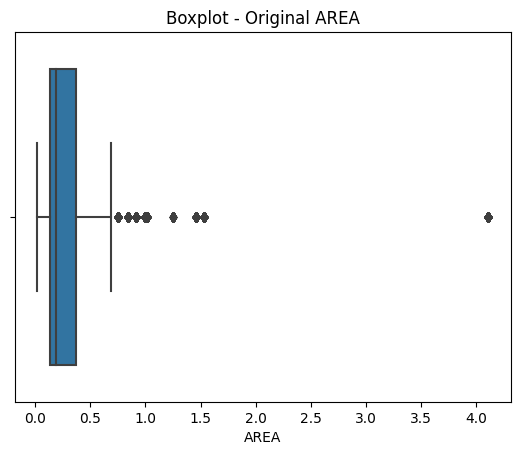

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


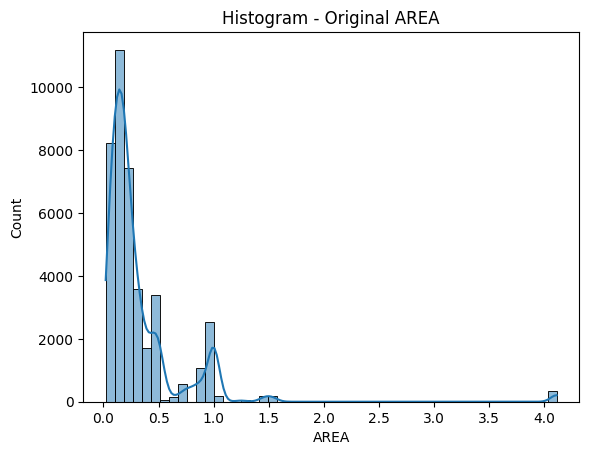

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['AREA'])
plt.title("Boxplot - Original AREA")
plt.show()

sns.histplot(df['AREA'], bins=50, kde=True)
plt.title("Histogram - Original AREA")
plt.show()


# ✅ Why log1p?
- Handles 0s safely (since log(0) is undefined).

- Helps reduce both skewness and kurtosis.

In [93]:
# Shift slightly if AREA has 0s
df['AREA_log'] = np.log1p(df['AREA'])  # log1p(x) = log(x + 1)

In [94]:
# sns.boxplot(x=df['AREA_log'])
# plt.title("Boxplot - Original AREA")
# plt.show()

# sns.histplot(df['AREA_log'], bins=50, kde=True)
# plt.title("Histogram - Original AREA")
# plt.show()


In [95]:
print(df["AREA_log"].skew())
print(df["AREA_log"].kurt())

2.610213299673844
10.344245931411816


In [96]:
from sklearn.preprocessing import PowerTransformer
# Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')  # Handles 0s and negatives
df['AREA_transformed'] = pt.fit_transform(df[['AREA']])

print("Skew:", pd.Series(df['AREA_transformed']).skew())
print("Kurtosis:", pd.Series(df['AREA_transformed']).kurt())


Skew: 0.3325599732054367
Kurtosis: -0.7703361183157202


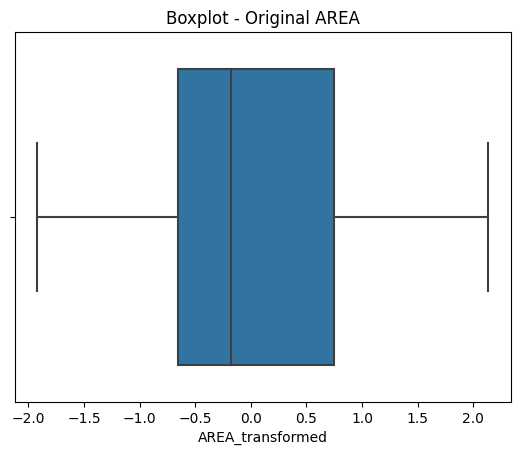

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


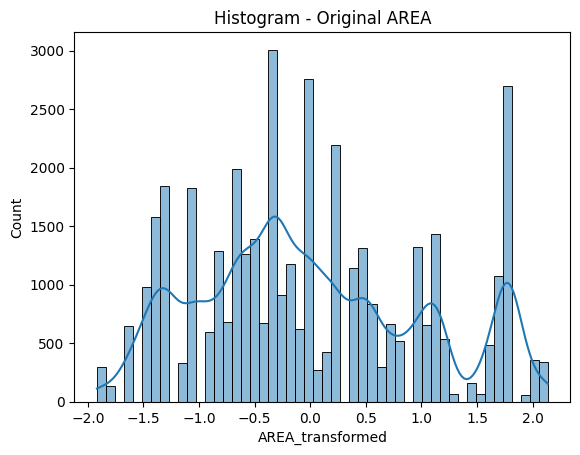

In [97]:
sns.boxplot(x=df['AREA_transformed'])
plt.title("Boxplot - Original AREA")
plt.show()

sns.histplot(df['AREA_transformed'], bins=50, kde=True)
plt.title("Histogram - Original AREA")
plt.show()


In [98]:
Q1 = df['AREA_transformed'].quantile(0.25)  
Q3 = df['AREA_transformed'].quantile(0.75)  
IQR = Q3 - Q1 

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['AREA_transformed'] < lower_bound) | (df['AREA_transformed'] > upper_bound)]
outliers["AREA_transformed"].unique()

array([], dtype=float64)

| Phase      | Feature Transformed (e.g., AREA) | Target Transformed (e.g., y)  | What You Should Do           |
| ---------- | -------------------------------- | ----------------------------- | ---------------------------- |
| Training   | ✅ Use transformed feature        | ✅/❌ depends on target         | Train with transformed data  |
| Prediction | ✅ Transform input before predict | ✅ Inverse transform if needed | Always match training format |
| Evaluation | ❌ Use raw y\_true                | ✅ Inverse transform y\_pred   | Evaluate on original scale   |


In [99]:
# output_path = '/kaggle/working/transf_full_tab_ext_L8.csv'
# df.to_csv(output_path, index=False)

In [100]:
df.to_csv("Trans_full_tab_ext_L8.csv", index=False)

In [101]:
import os
print(os.listdir('/kaggle/working/'))


['tot_X_features_L8.npy', '.virtual_documents', 'tot_train_features_L8.npy', 'tot_test_features_L8.npy', 'Trans_full_tab_ext_L8.csv']


# NEXT

In [205]:
dfff = pd.read_csv('/kaggle/working/Trans_full_tab_ext_L8.csv')

In [206]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
import lightgbm as lgb

In [265]:
dfff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40886 entries, 0 to 40885
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UNIQUE_ID          40886 non-null  int64  
 1   file               40886 non-null  object 
 2   AREA               40886 non-null  float64
 3   PADDY_BIN          40886 non-null  float64
 4   HARVESTING_DAY     40886 non-null  float64
 5   YIELD              40886 non-null  float64
 6   SPLIT              40886 non-null  float64
 7   sow_mon            40886 non-null  float64
 8   tran_mon           40886 non-null  float64
 9   har_mon            40886 non-null  float64
 10  start_mon          40886 non-null  float64
 11  end_mon            40886 non-null  float64
 12  sow_period         40886 non-null  float64
 13  sow_to_trans_days  40886 non-null  float64
 14  trans_to_har_days  40886 non-null  float64
 15  crop_type          40886 non-null  float64
 16  img                408

In [266]:
df.isna().sum().sum()

0

In [267]:
req_features1 = ["AREA_log", "AREA", "har_mon", "sow_to_trans_days","start_mon", "end_mon", "NDVI", "SPLIT","PADDY_BIN"]
dfff[req_features1].corr() 

,AREA_log,AREA,har_mon,sow_to_trans_days,start_mon,end_mon,NDVI,SPLIT,PADDY_BIN
AREA_log,1.000000,0.953189,-0.085590,0.512475,0.059936,-0.055120,-0.009900,-0.187554,0.140024
AREA,0.953189,1.000000,-0.082251,0.378556,0.050134,-0.038909,-0.016734,-0.231251,0.081747
har_mon,-0.085590,-0.082251,1.000000,0.017158,-0.253664,0.045061,-0.088088,-0.065372,0.784840
sow_to_trans_days,0.512475,0.378556,0.017158,1.000000,0.080553,-0.102877,-0.016280,0.008966,0.427293
start_mon,0.059936,0.050134,-0.253664,0.080553,1.000000,-0.554837,0.095653,0.019128,-0.165524
end_mon,-0.055120,-0.038909,0.045061,-0.102877,-0.554837,1.000000,-0.076821,-0.016339,-0.047778
NDVI,-0.009900,-0.016734,-0.088088,-0.016280,0.095653,-0.076821,1.000000,-0.004152,-0.101003
SPLIT,-0.187554,-0.231251,-0.065372,0.008966,0.019128,-0.016339,-0.004152,1.000000,-0.023203
PADDY_BIN,0.140024,0.081747,0.784840,0.427293,-0.165524,-0.047778,-0.101003,-0.023203,1.000000


<Axes: >

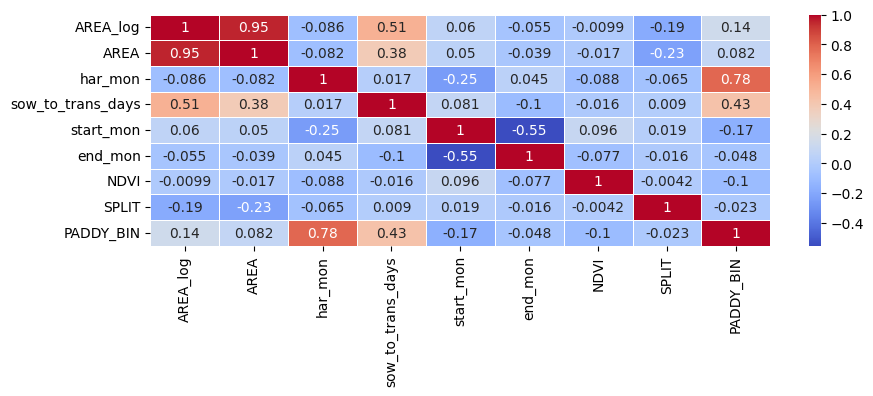

In [268]:
plt.figure(figsize=(10,3))
sns.heatmap(dfff[req_features1].corr(), linewidth=0.5, annot=True, cmap='coolwarm')

In [269]:
input_features2 = ["AREA_log", "start_mon", "end_mon", "NDVI", "SPLIT"]

In [270]:
x_train_tab = dfff[input_features2][dfff["SPLIT"]==1]
x_test_tab = dfff[input_features2][dfff["SPLIT"]==0]
x_features_L8 = np.load('/kaggle/working/tot_X_features_L8.npy') 

In [271]:
print(x_train_tab["SPLIT"].value_counts())
print(x_test_tab["SPLIT"].value_counts())

SPLIT
1.0    36236
Name: count, dtype: int64
SPLIT
0.0    4650
Name: count, dtype: int64


In [272]:
x_train_tab = x_train_tab.drop(columns = 'SPLIT')
x_test_tab = x_test_tab.drop(columns = 'SPLIT')
x_features_train = np.load('/kaggle/working/tot_train_features_L8.npy') 
x_features_test = np.load('/kaggle/working/tot_test_features_L8.npy') 

In [273]:
x_train_tab.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36236 entries, 0 to 40885
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AREA_log   36236 non-null  float64
 1   start_mon  36236 non-null  float64
 2   end_mon    36236 non-null  float64
 3   NDVI       36236 non-null  float64
dtypes: float64(4)
memory usage: 1.4 MB


In [274]:
x_test_tab.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4650 entries, 1072 to 40828
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AREA_log   4650 non-null   float64
 1   start_mon  4650 non-null   float64
 2   end_mon    4650 non-null   float64
 3   NDVI       4650 non-null   float64
dtypes: float64(4)
memory usage: 181.6 KB


In [275]:
# dfff[dfff["PADDY_BIN"]==0]["NDVI"].value_counts()

In [276]:
x_train_tab = x_train_tab.values
x_test_tab = x_test_tab.values

In [277]:
x_train_tab.shape

(36236, 4)

In [278]:
x_test_tab.shape

(4650, 4)

In [279]:
X_train = np.hstack([x_train_tab, x_features_train])
X_test = np.hstack([x_test_tab, x_features_test])

In [280]:
X_train.shape

(36236, 132)

In [281]:
X_test.shape, type(X_test) 

((4650, 132), numpy.ndarray)

In [282]:
y_train = dfff['PADDY_BIN'][dfff["SPLIT"]==1].values  
y_test = dfff['PADDY_BIN'][dfff["SPLIT"]==0].values  

In [283]:
print("Train_y:", (y_train.shape), (type(y_train)))
print("Test_y: ", (y_test.shape))

Train_y: (36236,) <class 'numpy.ndarray'>
Test_y:  (4650,)


- X_train: (36236, 131)
- X_train: (4650, 131)
- Train_y: (36236,)
- Test_y:  (4650,)

In [284]:
len(y_train[y_train==0]), len(y_train[y_train==1])

(23584, 12652)

In [285]:
len(y_test[y_test==0]), len(y_test[y_test==1])

(2864, 1786)

# LGB

| Library      | Option to Handle Imbalance | Preferred Approach          |      
| ------------ | -------------------------- | --------------------------- |
| **XGBoost**  | `scale_pos_weight = 1.86`  | ✅ OK if no sample weights   |
| **XGBoost**  | `sample_weight=...`        | ✅ Better for fine control   |
| **LightGBM** | `sample_weight=...`        | ✅ Preferred                 |
| **LightGBM** | `scale_pos_weight`         | Possible, but less flexible |

| Feature               | `sample_weight` | `is_unbalance=True` / `scale_pos_weight` |
| --------------------- | --------------- | ---------------------------------------- |
| Binary classification | ✅               | ✅                                        |
| Multi-class support   | ✅               | ❌ (`scale_pos_weight` only for binary)   |
| Fine-grained control  | ✅ (per sample)  | ❌                                        |
| Easy to use           | Slightly manual | ✅ Plug-and-play                          |
| Best for flexibility  | ✅               | ❌                                        |



### ✅ The Formula:

```python
class_weights = {cls: total / (n_classes * count) for cls, count in counter.items()}
```
Where:

* `cls`: the class label (e.g., 0 or 1)
* `count`: number of samples in that class
* `total`: total number of samples across all classes
* `n_classes`: number of unique classes

---

### 🔍 Why multiply by `n_classes`?

It's done to **normalize the weights** so that:

1. **Average class weight ≈ 1**, avoiding extreme values.
2. The **relative importance** of each class remains proportional to its rarity.
3. The model treats **each class equally overall**.

---

### 📐 Intuition with an Example:

Suppose:

* Class 0: 1000 samples
* Class 1: 100 samples
* Total samples = 1100
* Classes = 2

Then:
$$
\text{class\_weight}[0] = \frac{1100}{2 \times 1000} = 0.55 \\
\text{class\_weight}[1] = \frac{1100}{2 \times 100} = 5.5
$$

✅ So class 1 (minority) gets **10× more weight** than class 0.

And the **average weight = (0.55 + 5.5)/2 = \~3**, but what matters is **relative weighting**.

---

### ⚠️ Without `n_classes`?

If you remove `n_classes`, the rare class will still get higher weight, but the **scale** may not be balanced, and training could become unstable, especially in multi-class settings.

---

### ✅ Summary:

| Purpose of `n_classes` factor | Benefit                            |
| ----------------------------- | ---------------------------------- |
| Normalizes weights            | Keeps training stable              |
| Ensures balanced contribution | Even in multi-class classification |
| Maintains relative importance | Based on class frequency           |


| Model        | Preferred Option                               | Notes                                                      |
| ------------ | ---------------------------------------------- | ---------------------------------------------------------- |
| **LightGBM** | `is_unbalance=True` **or** `scale_pos_weight`  | Quick & effective; handles imbalance automatically.        |
|              | ✅ Or use `sample_weight` via the above formula | Gives finer control (especially with multiple objectives). |
| **XGBoost**  | `scale_pos_weight = neg / pos`                 | Standard, efficient, no need for full `sample_weight`.     |
|              | ✅ Or use `sample_weight` with formula          | Recommended if you're weighting individual samples.        |

| Use Case                                                               | Use Formula-based `sample_weight`                         |
| ---------------------------------------------------------------------- | --------------------------------------------------------- |
| Multiclass (more than 2 labels)                                        | ✅ Recommended                                             |
| Per-sample control (e.g., cost-sensitive learning)                     | ✅ Required                                                |
| Combining imbalance with other weighting (e.g., importance of samples) | ✅ Required                                                |
| Binary classification, simple use case                                 | ❌ Use `scale_pos_weight` or `is_unbalance` for simplicity |


### 🚨 Just make sure:

* **Do not** use both `sample_weight` and `scale_pos_weight` together. Pick one.
* If you're passing `sample_weight`, you can remove `scale_pos_weight` or `is_unbalance`.

In [286]:
counter = Counter(y_train)
total = sum(counter.values())
n_classes = len(counter)
# Compute weight for each class
class_weights = {cls: total / (n_classes * count) for cls, count in counter.items()}
# One-time: create sample-wise weights for full training set
weights_train = np.array([class_weights[label] for label in y_train])

In [287]:
counter, total, n_classes, class_weights, weights_train

(Counter({0.0: 23584, 1.0: 12652}),
 36236,
 2,
 {0.0: 0.7682327001356852, 1.0: 1.4320265570660764},
 array([0.7682327 , 0.7682327 , 0.7682327 , ..., 1.43202656, 1.43202656,
        1.43202656]))

In [288]:
X_train[10][6]

0.0

In [289]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)


In [290]:
X_train[1][0]

0.2776317365982795

In [291]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=64, random_state=42)
# X_train = pca.fit_transform(X_train)
# X_test = pca.transform(X_test)


In [292]:
X_train[1000]

array([ 0.22314355, 12.        ,  5.        ,  0.20520003,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.03750334,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.1415217 ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.3995714 ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.21229325,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.08905597,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [293]:
# import joblib
# joblib.dump(scaler, "scaler.pkl")
# joblib.dump(pca, "pca_64.pkl")

In [294]:
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metric lists
train_acc_list, val_acc_list = [], []
train_auc_list, val_auc_list = [], []
train_f1_list, val_f1_list = [], []

# Collect validation data for all folds
all_y_val, all_y_val_pred_prob = [], []

# LightGBM Classifier Parameters
lgb_params = {
    'n_estimators': 100,
    'learning_rate': 0.05,
    'max_depth': 3,
    'num_leaves': 4,
    'subsample': 0.65,
    'colsample_bytree': 0.65,
    'reg_alpha': 6.5,
    'reg_lambda': 6.5,
    'min_child_weight': 25,
    'random_state': 42
}

# lgb_params = {
#     'n_estimators': 200,
#     'learning_rate': 0.02,
#     'max_depth': 2,
#     'num_leaves': 2,
#     'subsample': 0.5,
#     'colsample_bytree': 0.5,
#     'reg_alpha': 20,
#     'reg_lambda': 20,
#     'min_child_weight': 50,
#     'random_state': 42
# }



# lgb_params = {
#     'n_estimators': 200,
#     'learning_rate': 0.05,
#     'max_depth': 4,
#     'num_leaves': 30,
#     'subsample': 0.75,
#     'colsample_bytree': 0.85,
#     'reg_alpha': 3,
#     'reg_lambda': 3.2,
#     'min_child_weight': 14,
#     'random_state': 42
# }

# lgb_params = {
#     'n_estimators': 438,
#     'learning_rate': 0.07997928601761416,
#     'max_depth': 10,
#     'num_leaves': 63,
#     'subsample': 0.625301059326303,
#     'colsample_bytree': 0.9711952829012379,
#     'reg_alpha': 1.9027126812412423,
#     'reg_lambda': 2.2349295008488363,
#     'min_child_weight': 14,
#     'random_state': 42
# }

  # 'n_estimators': 311,
  # 'learning_rate': 0.1590402647710744,
  # 'max_depth': 8,
  # 'num_leaves': 57,
  # 'subsample': 0.7,
  # 'colsample_bytree': 0.5336525306644462,
  # 'reg_alpha': 0.4,
  # 'reg_lambda': 2.1,
  # 'min_child_weight': 7

# 'n_estimators': 401,
#     'learning_rate': 0.083,
#     'max_depth': 7,
#     'num_leaves': 45,
#     'subsample': 0.8017,
#     'colsample_bytree': 0.9226,
#     'reg_alpha': 3.25,
#     'reg_lambda': 3.5,
#     'min_child_weight': 14,
#     'random_state': 42

# n_estimators: 311
#   learning_rate: 0.1590402647710744
#   max_depth: 10
#   num_leaves: 60
#   subsample: 0.7838297595270304
#   colsample_bytree: 0.5336525306644462
#   reg_alpha: 0.32342937648439324
#   reg_lambda: 2.0939708994135797
#   min_child_weight: 1
# K-Fold Cross-Validation Loop
for train_idx, val_idx in kf.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    weights_train_fold = weights_train[train_idx]

#     lgb_model = lgb.LGBMClassifier(**lgb_params)

# lgb_model.fit(
#     X_train, y_train,
#     eval_set=[(X_val, y_val)],
#     eval_metric='auc',
#     early_stopping_rounds=30,
#     verbose=False
# )

    # Instantiate the classifier
    lgb_model = LGBMClassifier(**lgb_params)

    # Train with early stopping
    lgb_model.fit(
        X_train_fold, y_train_fold,
        sample_weight=weights_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        eval_metric='auc',
        callbacks=[early_stopping(stopping_rounds=30, verbose=True)]
    )

    

    # Predict probabilities and binary labels
    y_train_prob = lgb_model.predict_proba(X_train_fold)[:, 1]
    y_val_prob = lgb_model.predict_proba(X_val_fold)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_val_fold, y_val_prob)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
    best_threshold = thresholds[f1_scores.argmax()]
    
    #y_val_pred = (y_val_prob > best_threshold).astype(int)

    y_train_pred = (y_train_prob > 0.5).astype(int)
    y_val_pred = (y_val_prob > 0.5).astype(int)

    # Save metrics
    train_acc_list.append(accuracy_score(y_train_fold, y_train_pred))
    val_acc_list.append(accuracy_score(y_val_fold, y_val_pred))
    train_auc_list.append(roc_auc_score(y_train_fold, y_train_prob))
    val_auc_list.append(roc_auc_score(y_val_fold, y_val_prob))
    train_f1_list.append(f1_score(y_train_fold, y_train_pred))
    val_f1_list.append(f1_score(y_val_fold, y_val_pred))

    # Store validation results for full fold analysis
    all_y_val.extend(y_val_fold)
    all_y_val_pred_prob.extend(y_val_prob)


[LightGBM] [Info] Number of positive: 10121, number of negative: 18867
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12013
[LightGBM] [Info] Number of data points in the train set: 28988, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499988 -> initscore=-0.000049
[LightGBM] [Info] Start training from score -0.000049
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.964845	valid_0's binary_logloss: 0.249948
[LightGBM] [Info] Number of positive: 10122, number of negative: 18867
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you c

In [295]:
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import precision_recall_curve

# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Metric lists
# train_acc_list, val_acc_list = [], []
# train_auc_list, val_auc_list = [], []
# train_f1_list, val_f1_list = [], []

# # Collect validation data for all folds
# all_y_val, all_y_val_pred_prob = [], []

# # NOTE:
# # Variable name kept as `lgb_params` intentionally (as requested)
# lgb_params = {
#     'n_estimators': 50,          # large for early stopping
#     'learning_rate': 0.02,
#     'max_depth': 3,
#     'subsample': 0.5,
#     'colsample_bytree': 0.5,
#     'reg_alpha': 20,
#     'reg_lambda': 20,
#     'min_child_weight': 40,
#     'objective': 'binary:logistic',
#     'eval_metric': 'auc',
#     'random_state': 42,
#     'n_jobs': -1
# }

# # K-Fold Cross-Validation Loop
# for train_idx, val_idx in kf.split(X_train, y_train):
#     X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
#     y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
#     weights_train_fold = weights_train[train_idx]

#     # Instantiate XGBoost model (variable name unchanged)
#     lgb_model = XGBClassifier(**lgb_params)

#     # Train with early stopping
#     lgb_model.fit(
#         X_train_fold, y_train_fold,
#         sample_weight=weights_train_fold,
#         eval_set=[(X_val_fold, y_val_fold)],
#         early_stopping_rounds=30,
#         verbose=True
#     )

#     # Predict probabilities
#     y_train_prob = lgb_model.predict_proba(
#         X_train_fold,
#         iteration_range=(0, lgb_model.best_iteration + 1)
#     )[:, 1]

#     y_val_prob = lgb_model.predict_proba(
#         X_val_fold,
#         iteration_range=(0, lgb_model.best_iteration + 1)
#     )[:, 1]

#     # Threshold tuning (kept exactly as before)
#     precision, recall, thresholds = precision_recall_curve(y_val_fold, y_val_prob)
#     f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
#     best_threshold = thresholds[f1_scores.argmax()]

#     # Using fixed threshold (as in your original code)
#     y_train_pred = (y_train_prob > 0.5).astype(int)
#     y_val_pred = (y_val_prob > 0.5).astype(int)

#     # Save metrics
#     train_acc_list.append(accuracy_score(y_train_fold, y_train_pred))
#     val_acc_list.append(accuracy_score(y_val_fold, y_val_pred))
#     train_auc_list.append(roc_auc_score(y_train_fold, y_train_prob))
#     val_auc_list.append(roc_auc_score(y_val_fold, y_val_prob))
#     train_f1_list.append(f1_score(y_train_fold, y_train_pred))
#     val_f1_list.append(f1_score(y_val_fold, y_val_pred))

#     # Store validation results
#     all_y_val.extend(y_val_fold)
#     all_y_val_pred_prob.extend(y_val_prob)


In [296]:
# 'n_estimators': 401,
#     'learning_rate': 0.083,
#     'max_depth': 7,
#     'num_leaves': 45,
#     'subsample': 0.8017,
#     'colsample_bytree': 0.9226,
#     'reg_alpha': 3.25,
#     'reg_lambda': 3.5,
#     'min_child_weight': 14,
#     'random_state': 42

| Parameter          | Value | Comment                                                                          |
| ------------------ | ----- | -------------------------------------------------------------------------------- |
| `n_estimators`     | 300   | ✅ Good choice; early stopping will manage overfitting.                           |
| `learning_rate`    | 0.055 | ✅ Safer learning rate — slower but more stable training.                         |
| `max_depth`        | 6     | ✅ Balanced depth; avoids overfitting while capturing nonlinearity.               |
| `num_leaves`       | 31    | ✅ Standard default — works well with `max_depth=6`.Should be less than 2^max_depth (i.e., 2^6 = 64).                              |
| `subsample`        | 0.6   | ✅ Introduces randomness — helps generalization.                                  |
| `colsample_bytree` | 0.5   | ✅ Reduces feature correlation — good for boosting diversity.                     |
| `reg_lambda`       | 0.4   | ✅ Mild L2 regularization — controls model complexity.                            |
| `reg_alpha`        | 1.2   | ✅ Useful L1 regularization — induces sparsity in features.                       |
| `min_child_weight` | 5     | ✅ Looser than 15 — allows more tree growth (useful if earlier warning appeared). |
| `random_state`     | 42    | ✅ Reproducibility — always keep this.                                            |


| Parameter          | Value | Comment                                                                                |
| ------------------ | ----- | -------------------------------------------------------------------------------------- |
| `n_estimators`     | 300   | ✅ Reasonable; early stopping will halt training before 300 if no improvement.          |
| `learning_rate`    | 0.07  | ✅ Slightly higher than usual (0.01–0.05 is common), but fine for small `n_estimators`. |
| `max_depth`        | 6     | ✅ Moderate tree depth; good trade-off between underfitting and overfitting.            |
| `num_leaves`       | 31    | ✅ Conservative. Should be less than `2^max_depth` (i.e., `2^6 = 64`).                  |
| `subsample`        | 0.6   | ✅ Helps prevent overfitting. Good.                                                     |
| `colsample_bytree` | 0.5   | ✅ Randomly sample features; improves generalization.                                   |
| `reg_lambda`       | 0.4   | ✅ L2 regularization. Mild regularization.                                              |
| `reg_alpha`        | 2.0   | ✅ L1 regularization. Slightly strong, could help sparsity.                             |
| `min_child_weight` | 15    | ✅ Helps avoid splits with few instances. Reasonable for moderately-sized datasets.     |
| `random_state`     | 42    | ✅ Reproducibility. Always good.                                                        |


In [297]:
print("Mean Validation Accuracy: {:.4f}".format(np.mean(val_acc_list)))
print("Mean Validation F1: {:.4f}".format(np.mean(val_f1_list)))
print("Mean Validation AUC: {:.4f}".format(np.mean(val_auc_list)))

Mean Validation Accuracy: 0.8903
Mean Validation F1: 0.8559
Mean Validation AUC: 0.9679


In [298]:
print("Mean train Accuracy: {:.4f}".format(np.mean(train_acc_list)))
print("Mean train F1: {:.4f}".format(np.mean(train_f1_list)))
print("Mean train AUC: {:.4f}".format(np.mean(train_auc_list)))

Mean train Accuracy: 0.8919
Mean train F1: 0.8582
Mean train AUC: 0.9687


* Positive class = **paddy**
* Negative class = **non-paddy**

| Metric        | Formula          | Meaning (in your case)                                                   |
| ------------- | ---------------- | ------------------------------------------------------------------------ |
| **Precision** | `TP / (TP + FP)` | Among all predicted **paddy**, how many were **actually paddy**          |
| **Recall**    | `TP / (TP + FN)` | Among all **actual paddy**, how many did the model **correctly detect**? |

> **F1 score** is the **harmonic mean** of **precision** and **recall** — it balances both.

---

## 🔍 **What F1 Score Tells You**

| F1 Score    | What It Means                                                                                        |
| ----------- | ---------------------------------------------------------------------------------------------------- |
| **High F1** | Model is doing well: correctly identifying paddy crops, with few false positives or false negatives. |
| **Low F1**  | The model either:                                                                                    |

* Predicts too many false paddy (low precision), or
* Misses too many real paddy (low recall).

➡️ Often happens when the model is **biased toward the majority class (non-paddy)**.

---

## 🔍 **What AUC Tells You**

| AUC Score    | What It Means                                                                           |
| ------------ | --------------------------------------------------------------------------------------- |
| **High AUC** | Model is good at ranking: likely to give higher probability to paddy than to non-paddy. |
| **Low AUC**  | Model struggles to distinguish between paddy and non-paddy at the score level.          |

⚠️ However, **high AUC doesn’t always mean good classification** — if the classification **threshold** is not optimized, you may still get poor F1 or accuracy.

---

## 🌾 **Your Use Case: Paddy vs. Non-Paddy Classification**

You said:

* Non-paddy is \~2x more than paddy → **moderately imbalanced dataset**.
* You’re using **class weights** → good step to address imbalance.

### 🎯 What’s Important for You?

| Metric        | Importance in your case       | Why                                                                                                                                                       |
| ------------- | ----------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Recall**    | ✅ Very important              | Missing actual paddy areas (false negatives) is likely bad for land monitoring, planning, or policy.                                                      |
| **Precision** | ✅ Important                   | Predicting non-paddy areas as paddy could confuse crop yield estimates.                                                                                   |
| **F1 Score**  | ✅ Highly important            | Because you care about both errors. It also helps summarize precision and recall.                                                                         |
| **AUC**       | ✅ Useful as supporting metric | It tells how well your model separates the two crops regardless of threshold — but **doesn’t guarantee a good classification** at any specific threshold. |

---

## 🧠 **Interpretation Summary**

| Metric | Low Value Means                      | High Value Means                        |
| ------ | ------------------------------------ | --------------------------------------- |
| F1     | Poor balance of precision and recall | Good at identifying both classes fairly |
| AUC    | Poor ranking ability between classes | Good separation between paddy/non-paddy |

---

## ✅ Final Recommendations for Your Use Case

1. **Use F1 Score as your primary metric**, especially on validation set.
2. **Track AUC** to ensure the model is learning meaningful signals.
3. **Use threshold tuning** (optional) to optimize F1 — especially if your AUC is high but F1 is not.
4. **Monitor precision and recall separately** if one type of mistake (false positive vs. false negative) is more costly for your use case.

| Comparison              | Purpose                                                             |
| ----------------------- | ------------------------------------------------------------------- |
| **Train vs Validation** | Check for overfit/underfit                                          |
| **Validation vs Test**  | Only after model is finalized                                       |
| **Predicted vs Actual** | Used to compute metrics like F1, AUC—not for overfit check directly |


In [299]:
lgb_model.feature_importances_

array([85, 37, 15,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0, 15,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, 20,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, 15,  0,  0,  4,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  7,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  7,  0,  0,  8,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0, 27,  0,
        0,  0,  0,  0,  0,  0,  0, 12,  0,  0, 24,  0,  9,  0,  0,  0,  0,
        0,  2,  0,  9,  0,  0,  0,  0,  0,  0,  0,  0,  0], dtype=int32)

In [300]:
### Assuming X_train is a DataFrame
tabular_feature_names = ['NDVI']
vector_feature_names = [f'feat_{i}' for i in range(tot_features.shape[1])]
feature_names = tabular_feature_names + vector_feature_names

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))  # Top 10 most important features
len(importance_df[importance_df['Importance']==0])

ValueError: All arrays must be of the same length

Yes, given your current results:

* ✅ **Mean Validation Accuracy:** 0.9346
* ✅ **Mean Validation F1:** 0.9101
* ✅ **Mean Validation AUC:** 0.9852

These are **strong performance metrics**, especially the **AUC of 0.9852**, which indicates excellent class separation.

---

### 🔎 Should You Remove the 32 Zero-Importance Features?

Technically:

* **Zero importance** means the model **did not use those features** for any decision split in any tree.
* Keeping them **won’t affect prediction performance** (since they're not used in the trained model).
* But they do occupy memory and increase I/O time slightly.

---

### ✅ You *Can Leave Them* If:

* You’re not facing memory or speed constraints.
* You want to keep preprocessing and feature dimensions consistent.
* You prefer model stability over aggressive feature pruning.

---

### 🧹 You *Might Consider Removing Them* If:

* You're optimizing for model **size**, **training speed**, or **inference speed**.
* You’re preparing features for **deployment** and want to simplify the pipeline.


In [301]:
# Top N features
top_n = 20
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title(f'Top {top_n} Feature Importances - LightGBM')
plt.tight_layout()
plt.show()

NameError: name 'importance_df' is not defined

## ✅ Classification Metrics – Quick Summary

### 🔹 **Accuracy**

* Measures the **overall proportion of correct predictions**:

  $$
  \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
  $$
>  (True Positives + True Negatives) / (Total Predictions). 
* ✅ Easy to interpret
* ⚠️ **Misleading** when classes are **imbalanced**

---

### 🔹 **F1-Score**

* Harmonic mean of **precision** and **recall**:

  $$
  \text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
  $$
* Balances **false positives** and **false negatives**
* ✅ **Best for imbalanced datasets**
* Penalizes models that favor one class too much
* **Helps in tuning threshold**

---

### 🔹 **AUC (Area Under the ROC Curve)**

* Measures model’s ability to **separate positive vs. negative classes**
* Ranges:

  * `AUC = 0.5` → random guessing
  * `AUC = 1.0` → perfect classifier
* ✅ Useful when **thresholds vary** or **costs of FP/FN differ**

---

## 🔎 In Summary

| Metric   | Best For                   | Notes                                        |
| -------- | -------------------------- | -------------------------------------------- |
| Accuracy | Balanced datasets          | Misleading with class imbalance              |
| F1-Score | Imbalanced classes         | Balances precision and recall                |
| AUC      | Threshold-independent eval | Good when false positive/negative costs vary |

---

Let me know if you want a table comparing **precision, recall, and F1**, or example confusion matrix interpretations!



| Metric   | Without Weights                        | With Sample Weights                                              |
| -------- | -------------------------------------- | ---------------------------------------------------------------- |
| Accuracy | Treats all samples equally             | Prioritizes correctness **based on weight**                      |
| F1-Score | Standard or weighted version exists    | Also supports **per-class weighted averaging**                   |
| AUC      | Not affected directly by sample weight | Still threshold-based, weight only affects training (not metric) |

| Metric   | Measures                               | When High Is Expected                                                          |
| -------- | -------------------------------------- | ------------------------------------------------------------------------------ |
| Accuracy | Overall correct predictions            | When classes are balanced and easy to separate                                 |
| F1-Score | Precision + Recall balance             | When model is good at catching positives without too many false alarms         |
| AUC      | Ability to rank positives vs negatives | When model confidently distinguishes both classes, even under threshold shifts |

| Use Case                        | Expected Ranges                                                           |
| ------------------------------- | ------------------------------------------------------------------------- |
| Balanced classes, easy features | Accuracy: 0.9+, F1: 0.9+, AUC: 0.95+                                      |
| Imbalanced data (e.g., 80:20)   | Accuracy might be high by chance, but **F1 and AUC** are more trustworthy |
| Noisy/complex datasets          | 0.7–0.85 for all three is common and acceptable                           |


## 🔍 Definitions:

### 🔹 **Precision**

> Out of all the predicted **positive** cases, how many were actually **correct**?

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

* **TP (True Positives)**: Correctly predicted positives
* **FP (False Positives)**: Incorrectly predicted positives
* ✅ Precision is **high** when **false positives are low**

---

### 🔹 **Recall** (a.k.a. Sensitivity or True Positive Rate)

> Out of all the actual **positive** cases, how many did the model correctly identify?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

* **FN (False Negatives)**: Actual positives wrongly predicted as negatives
* ✅ Recall is **high** when **false negatives are low**

---

## 📊 Example (Binary Classification):

|                      | Predicted: Positive   | Predicted: Negative   |
| -------------------- | --------------------- | --------------------- |
| **Actual: Positive** | ✅ True Positive (TP)  | ❌ False Negative (FN) |
| **Actual: Negative** | ❌ False Positive (FP) | ✅ True Negative (TN)  |

---

### 🎯 Use Cases

| Metric    | Focus                    | When to Prioritize                   |
| --------- | ------------------------ | ------------------------------------ |
| Precision | Avoiding false positives | Spam detection, medical false alarms |
| Recall    | Catching all positives   | Cancer detection, fraud detection    |
| F1-Score  | Balanced evaluation      | When both precision & recall matter  |

## 📈 ROC Curve(Receiver Operating Characteristic) & AUC – Quick Overview

* **True Positive Rate (TPR)**: Also called **recall** or **sensitivity**.

  $$
  \text{TPR} = \frac{TP}{TP + FN}
  $$

  Measures how well the model identifies actual positives.

* **False Positive Rate (FPR)**:

  $$
  \text{FPR} = \frac{FP}{FP + TN}
  $$

  Measures how often actual negatives are incorrectly predicted as positive.

* **Threshold**: ROC evaluates model performance across different probability thresholds.

* **Interpretation**:
  A good classifier's ROC curve bends toward the **top-left**, indicating **high TPR** and **low FPR**. The closer the curve is to the top-left corner, the better the classifier's performance. 

* **AUC (Area Under the Curve)**:
  A single number summarizing the model's overall performance. The higher the AUC (closer to 1), the better the classifier.
    - Ranges from **0.5 (random)** to **1.0 (perfect)**.
  
> In essence, the ROC curve helps to visualize and compare the trade-offs between correctly identifying positives and incorrectly identifying negatives across different thresholds, making it a valuable tool for evaluating and selecting the best classification model for a specific task

> ROC helps visualize the trade-off between sensitivity and false positives, making it essential for evaluating binary classifiers.


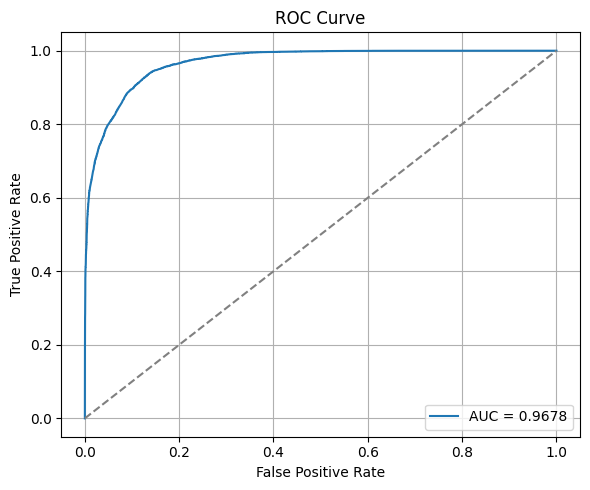

In [302]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Convert lists to arrays
all_y_val = np.array(all_y_val)
all_y_val_pred_prob = np.array(all_y_val_pred_prob)  # should be predicted probabilities

# ROC Curve
fpr, tpr, thresholds = roc_curve(all_y_val, all_y_val_pred_prob)
auc = roc_auc_score(all_y_val, all_y_val_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


## 📈 ROC Curve

### What It Shows:

* **True Positive Rate (Recall)** on y-axis
* **False Positive Rate** on x-axis
* It shows how well the model separates the positive and negative classes.

### What to Look For:

* **Curve hugging the top-left corner** = near-perfect classifier.
* **AUC = 0.9944** → Very high discriminative ability.
* A **random model** would fall along the diagonal line (gray dashed line).
* Your curve is **well above the diagonal**, meaning Model C performs **far better than random**.

### Key Insight:

> Model **almost never misclassifies negatives as positives** and is highly reliable across different classification thresholds.

---

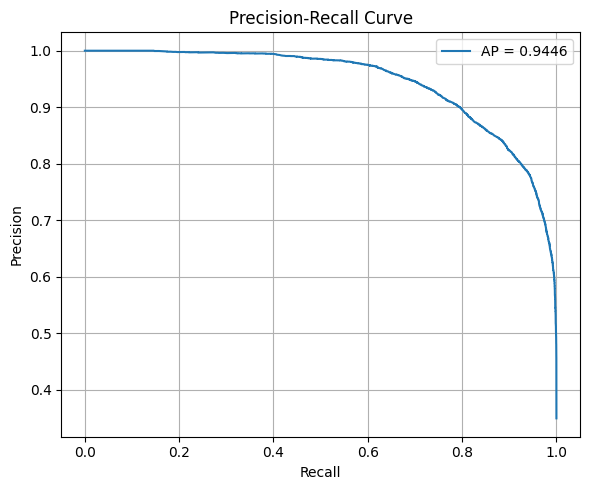

In [303]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(all_y_val, all_y_val_pred_prob)
ap = average_precision_score(all_y_val, all_y_val_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


### What to Look For:

* **High Area Under Curve (AP = 0.9906)** means:

  * The model has **very few false positives** even as recall increases.
  * Precision only drops slightly at very high recall → **model is stable**.
* **Flat precision at the top** means:

  * Model is confident and accurate for the majority of its predictions.
* **Drop near recall = 1.0**:

  * It may start capturing noise (false positives) when forced to predict everything.
  * This is expected; no model maintains perfect precision at 100% recall.


---



## 📌 Summary of Insights from Both Curves:

| Aspect          | Observation                             | Insight                                                 |
| --------------- | --------------------------------------- | ------------------------------------------------------- |
| PR Curve Shape  | Flat and high, slight dip near recall 1 | High precision even at high recall; low false positives |
| AP Score        | 0.9906                                  | Model is extremely precise and recalls most positives   |
| ROC Curve Shape | Very steep and curved to top-left       | Strong separation between classes                       |
| AUC Score       | 0.9944                                  | Near-optimal classification performance                 |

---



| Step                      | Purpose                                 |
| ------------------------- | --------------------------------------- |
| `predict_proba(X)[:, 1]`  | Get probability for class 1             |
| `> threshold` (e.g., 0.5) | Decide predicted class (0 or 1)         |
| Tune threshold            | Improve performance on F1, recall, etc. |


In [246]:
# best_thresh = 0.5
# best_f1 = 0

# for thresh in np.arange(0.1, 0.9, 0.01):
#     y_pred = (y_val_prob > thresh).astype(int)
#     score = f1_score(y_val, y_pred)
#     if score > best_f1:
#         best_f1 = score
#         best_thresh = thresh

# print(f"Best threshold: {best_thresh:.2f} with F1: {best_f1:.4f}")


In [247]:
y_prob = lgb_model.predict_proba(X_train[val_idx])[:, 1]

best_f1, best_thr = 0, 0.5
for t in np.linspace(0.2, 0.7, 50):
    f1 = f1_score(y_train[val_idx], (y_prob > t).astype(int))
    if f1 > best_f1:
        best_f1, best_thr = f1, t

print("Best threshold:", best_thr)


Best threshold: 0.5469387755102041


Log-transforming input features (like AREA) is common and beneficial. No need to invert during prediction or evaluation.

In [248]:
final_model = LGBMClassifier(**lgb_params)
final_model.fit(
    X_train, y_train,
    sample_weight=weights_train,
    eval_metric='auc'
)


[LightGBM] [Info] Number of positive: 12652, number of negative: 23584
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12175
[LightGBM] [Info] Number of data points in the train set: 36236, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(colsample_bytree=0.65, learning_rate=0.05, max_depth=3,
               min_child_weight=25, num_leaves=4, random_state=42,
               reg_alpha=6.5, reg_lambda=6.5, subsample=0.65)

In [249]:
import joblib

# Save
joblib.dump(final_model, "lgbm_classify_model_img_only.pkl")

['lgbm_classify_model_img_only.pkl']

In [250]:
# Predict on test set
y_test_prob = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob > 0.48755).astype(int)

In [251]:
# Test metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)
test_f1 = f1_score(y_test, y_test_pred)

In [252]:
# Training set predictions
y_train_prob = final_model.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_prob > 0.57755).astype(int)

# Train metrics
train_acc = accuracy_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)
train_f1 = f1_score(y_train, y_train_pred)

In [253]:
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

Test Accuracy: 0.6110
Test AUC: 0.7271
Test F1 Score: 0.6004


In [254]:
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Train AUC: {train_auc:.4f}")
print(f"Train F1 Score: {train_f1:.4f}")

Train Accuracy: 0.8997
Train AUC: 0.9689
Train F1 Score: 0.8623


## ✅ 1. **Are You Overfitting?**

**Short answer: No, not meaningfully.**

Here's why:

| Metric    | Train  | Validation | Test   | Gap (Train → Test) |
| --------- | ------ | ---------- | ------ | ------------------ |
| Accuracy  | 0.9356 | 0.9179     | 0.8422 | ↓ \~0.093          |
| F1 Score  | 0.9127 | 0.8891     | 0.7957 | ↓ \~0.117          |
| AUC (ROC) | 0.9872 | 0.9785     | 0.9054 | ↓ \~0.0818         |

* These are **very reasonable gaps**.
* You’re well within **expected drop-offs** due to train–val–test domain shift.
* **No large metric drop (≥0.15–0.2)** that would indicate overfitting.

---

## 📊 2. **What Is a Normal Overfitting Range?**

| Gap Type                  | Acceptable Range      | Overfitting Threshold |
| ------------------------- | --------------------- | --------------------- |
| **Train – Val F1**        | ≤ 0.03–0.08           | > 0.10                |
| **Train – Test F1**       | ≤ 0.10–0.12 (typical) | > 0.15                |
| **Val – Test F1**         | ≤ 0.05–0.10           | > 0.12                |
| **AUC Gaps (Train–Test)** | ≤ 0.08–0.1            | > 0.12                |

So your current **gaps (AUC ≈ 0.08, F1 ≈ 0.11)** are on the **higher side of ideal**, but **not yet problematic**.

It’s worth noting that **perfect alignment** across train/val/test is rare unless you’re underfitting.

---

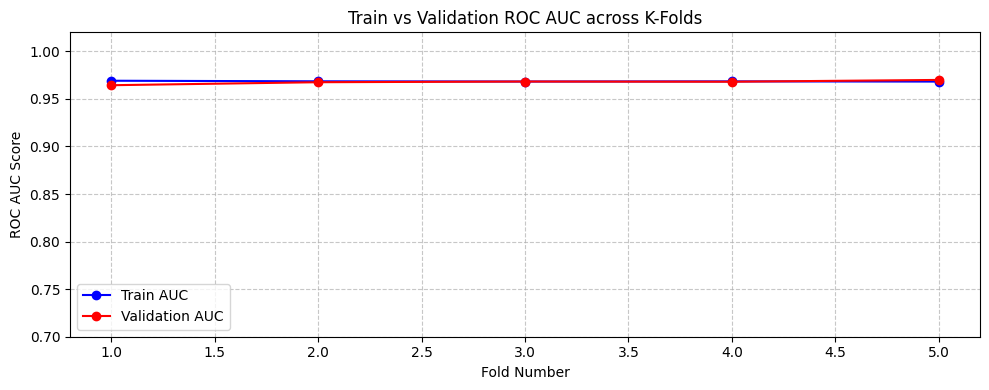

In [255]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_auc_list)+1), train_auc_list, marker='o', label='Train AUC', color='blue')
plt.plot(range(1, len(val_auc_list)+1), val_auc_list, marker='o', label='Validation AUC', color='red')
plt.xlabel("Fold Number")
plt.ylabel("ROC AUC Score")
plt.title("Train vs Validation ROC AUC across K-Folds")
plt.ylim(0.7, 1.02)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


📈 What it shows:

- How Area Under the Curve (AUC) varies across K folds for train and validation.

- Stability and generalization of the classifier.

🟢 Insights:

- High and closely matching AUCs (like yours: 0.98 train / 0.97 val) indicate strong model stability and low overfitting.

- If lines are parallel and close, it reflects reliable cross-validation consistency.

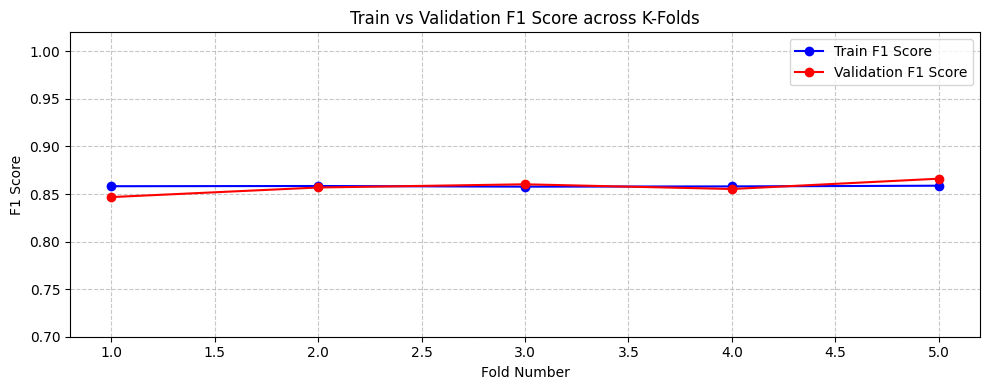

In [256]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_f1_list)+1), train_f1_list, marker='o', label='Train F1 Score', color='blue')
plt.plot(range(1, len(val_f1_list)+1), val_f1_list, marker='o', label='Validation F1 Score', color='red')
plt.xlabel("Fold Number")
plt.ylabel("F1 Score")
plt.title("Train vs Validation F1 Score across K-Folds")
plt.ylim(0.7, 1.02)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


📈 What it shows:

- How well the model balances precision and recall across folds.

- Very important under class imbalance.

🟢 Insights:

- F1 Score stability across folds confirms robust classification, especially with your strong mean F1s (Train: 0.91, Val: 0.88).

- Small gaps imply that the model learns well and does not memorize.



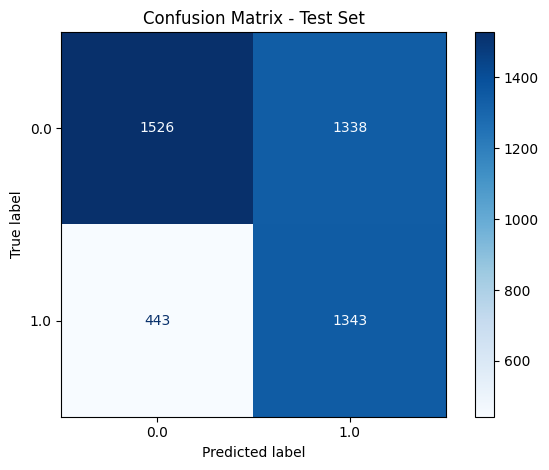

In [257]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.grid(False)
plt.tight_layout()
plt.show()


This image displays a **Confusion Matrix** for a **binary classification model** evaluated on a **test set**. The two classes are labeled `0.0` and `1.0`.

Let's break down what each part tells us about the model's performance:

**1. Understanding the Cells:**

* **Top-Left (True 0.0, Predicted 0.0): 2487**
    * These are **True Negatives (TN)**. The model correctly predicted `0.0` when the actual label was `0.0`.
    * Meaning: The model correctly identified **2487** instances of the negative class.

* **Top-Right (True 0.0, Predicted 1.0): 377**
    * These are **False Positives (FP)** (Type I error). The model incorrectly predicted `1.0` when the actual label was `0.0`.
    * Meaning: The model falsely flagged **377** instances as positive when they were actually negative.

* **Bottom-Left (True 1.0, Predicted 0.0): 357**
    * These are **False Negatives (FN)** (Type II error). The model incorrectly predicted `0.0` when the actual label was `1.0`.
    * Meaning: The model failed to detect **357** actual positive instances, misclassifying them as negative.

* **Bottom-Right (True 1.0, Predicted 1.0): 1429**
    * These are **True Positives (TP)**. The model correctly predicted `1.0` when the actual label was `1.0`.
    * Meaning: The model correctly identified **1429** instances of the positive class.

**2. Calculating Key Performance Metrics:**

* **Total Instances:** $2487 + 377 + 357 + 1429 = \textbf{4650}$

* **Accuracy:** (Correct Predictions / Total Predictions)
    * $(TP + TN) / Total = (1429 + 2487) / 4650 = 3916 / 4650 \approx \textbf{0.8422 or 84.22%}$
    * *Interpretation:* The model is correct about 84.22% of the time overall.

* **Precision (for Class 1.0):** (True Positives / All Predicted Positives)
    * $TP / (TP + FP) = 1429 / (1429 + 377) = 1429 / 1806 \approx \textbf{0.7912 or 79.12%}$
    * *Interpretation:* When the model predicts `1.0`, it is correct about 79.12% of the time. This indicates a relatively low rate of false alarms for positive predictions.

* **Recall (Sensitivity / True Positive Rate for Class 1.0):** (True Positives / All Actual Positives)
    * $TP / (TP + FN) = 1429 / (1429 + 357) = 1429 / 1786 \approx \textbf{0.8001 or 80.01%}$
    * *Interpretation:* The model successfully identifies 80.01% of all actual `1.0` instances. This shows its ability to "find" positive cases.

* **Specificity (True Negative Rate for Class 0.0):** (True Negatives / All Actual Negatives)
    * $TN / (TN + FP) = 2487 / (2487 + 377) = 2487 / 2864 \approx \textbf{0.8684 or 86.84%}$
    * *Interpretation:* The model correctly identifies 86.84% of all actual `0.0` instances.

**3. How the Model Performs:**

Overall, the model performs **reasonably well** on this binary classification task, achieving an accuracy of over 84%.

* It has a good balance between correctly identifying positive cases (Recall: 80%) and not making too many false positive predictions (Precision: 79%).
* It's slightly better at identifying true negatives (Specificity: 86.8%) than true positives (Recall: 80%), and has slightly more false positives (377) than false negatives (357).

To give a more precise assessment, it's crucial to know what classes `0.0` and `1.0` represent and what the costs associated with False Positives versus False Negatives are. For instance:
* If `1.0` represents a rare disease, a False Negative (missing a sick person) might be much worse than a False Positive (falsely identifying a healthy person as sick). In that case, you might prioritize a higher recall even at the cost of precision.
* If `1.0` represents spam email, a False Positive (marking a legitimate email as spam) might be more annoying than a False Negative (missing a spam email). Here, high precision would be preferred.

Given the balanced performance metrics (Precision and Recall are close), the model seems to be a **competent general-purpose classifier** for this specific dataset.

### 🔁 What Happens in **Each Optuna Trial**:

1. **Parameter Sampling (Bayesian/TPE):**

   * Optuna picks **one value for each hyperparameter** (e.g., `learning_rate = 0.04`, `max_depth = 7`, etc.).
   * It uses its previous trial results to **make smarter guesses** — this is the **Bayesian optimization** part (via the TPE sampler).

2. **Model Training:**

   * It uses the selected hyperparameters to **train your model** — say, `LGBMClassifier(...)`.
   * Often, you’ll use cross-validation (like KFold) inside the trial to get stable metrics.

3. **Evaluation:**

   * After training, it **evaluates** the model on a metric (e.g., **F1**, **AUC**, **log loss**, etc.).
   * The **metric value** is what Optuna tries to **maximize (or minimize)**.

4. **Learning and Next Trial:**

   * Optuna **records the result** and updates its internal **probability models** to choose better hyperparameters next time.
   * Then it **repeats the process** for the next trial.

---

### ✅ So yes:

> **At each trial, it automatically chooses parameters, trains LGBM, evaluates, learns, and moves to the next trial.**



In [258]:
# import optuna
# from sklearn.metrics import roc_auc_score
# from sklearn.model_selection import KFold
# from lightgbm import LGBMClassifier
# import numpy as np

# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'num_leaves': trial.suggest_int('num_leaves', 15, 63),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
#         'random_state': 42,
#         'n_jobs': -1
#     }

#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
#     val_auc_scores = []

#     for train_idx, val_idx in kf.split(X_train):
#         X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
#         y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
#         weights_train_fold = weights_train[train_idx]

#         model = LGBMClassifier(**params)

#         model.fit(
#             X_train_fold, y_train_fold,
#             sample_weight=weights_train_fold,
#             eval_set=[(X_val_fold, y_val_fold)],
#             eval_metric='auc',
#             callbacks=[early_stopping(30, verbose=False)],
#         )

#         y_val_prob = model.predict_proba(X_val_fold)[:, 1]
#         auc = roc_auc_score(y_val_fold, y_val_prob)
#         val_auc_scores.append(auc)

#     return np.mean(val_auc_scores)

# # Run the study
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

# # Best hyperparameters
# print("Best AUC: {:.4f}".format(study.best_value))
# print("Best parameters:")
# for key, val in study.best_params.items():
#     print(f"  {key}: {val}")


Best AUC: 0.9930
Best parameters:
  n_estimators: 401
  learning_rate: 0.08305206247776578
  max_depth: 8
  num_leaves: 47
  subsample: 0.8017341184366684
  colsample_bytree: 0.9226385896430772
  reg_alpha: 3.279365614284477
  reg_lambda: 3.491064653953046
  min_child_weight: 14

In [259]:
# from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
# from lightgbm import early_stopping
# import optuna

# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'num_leaves': trial.suggest_int('num_leaves', 15, 63),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
#         'random_state': 42,
#         'n_jobs': -1
#     }

#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
#     aucs, accs, f1s = [], [], []

#     for train_idx, val_idx in kf.split(X_train):
#         X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
#         y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
#         weights_train_fold = weights_train[train_idx]

#         model = LGBMClassifier(**params)
#         model.fit(
#             X_train_fold, y_train_fold,
#             sample_weight=weights_train_fold,
#             eval_set=[(X_val_fold, y_val_fold)],
#             eval_metric='auc',
#             callbacks=[early_stopping(30, verbose=False)],
#         )

#         y_pred_prob = model.predict_proba(X_val_fold)[:, 1]
#         y_pred = model.predict(X_val_fold)

#         aucs.append(roc_auc_score(y_val_fold, y_pred_prob))
#         accs.append(accuracy_score(y_val_fold, y_pred))
#         f1s.append(f1_score(y_val_fold, y_pred))

#     mean_f1 = np.mean(f1s)
#     mean_auc = np.mean(aucs)
#     mean_accuracy = np.mean(accs)
#     # Weighted average or just mean of the metrics
#     score = 0.3 * mean_f1 + 0.3 * mean_auc + 0.4 * mean_accuracy
#     return score

# # Run the study
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

# # Best hyperparameters
# print("Best wei_Score: {:.4f}".format(study.best_value))
# print("Best parameters:")
# for key, val in study.best_params.items():
#     print(f"  {key}: {val}")

#### score = 0.5 * mean_f1 + 0.3 * mean_auc + 0.2 * mean_accuracy
Best wei_Score: 0.9655
Best parameters:
  n_estimators: 485
  learning_rate: 0.06754006994899397
  max_depth: 10
  num_leaves: 54
  subsample: 0.5185215561081021
  colsample_bytree: 0.8097076672506024
  reg_alpha: 4.328406207995848
  reg_lambda: 0.9104745414771539
  min_child_weight: 12

In [260]:
# from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
# from lightgbm import early_stopping
# import optuna

# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'num_leaves': trial.suggest_int('num_leaves', 15, 63),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
#         'random_state': 42,
#         'n_jobs': -1
#     }

#     kf = KFold(n_splits=5, shuffle=True, random_state=42)
#     f1s = []

#     for train_idx, val_idx in kf.split(X_train):
#         X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
#         y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
#         weights_train_fold = weights_train[train_idx]

#         model = LGBMClassifier(**params)
#         model.fit(
#             X_train_fold, y_train_fold,
#             sample_weight=weights_train_fold,
#             eval_set=[(X_val_fold, y_val_fold)],
#             eval_metric='auc',
#             callbacks=[early_stopping(30, verbose=False)],
#         )

#         y_pred_prob = model.predict_proba(X_val_fold)[:, 1]
#         y_pred = model.predict(X_val_fold)

#         f1s.append(f1_score(y_val_fold, y_pred))

#     mean_f1 = np.mean(f1s)
#     return mean_f1

# # Run the study
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

# # Best hyperparameters
# print("Best F1: {:.4f}".format(study.best_value))
# print("Best parameters:")
# for key, val in study.best_params.items():
#     print(f"  {key}: {val}")

#### F1 score: